# MKA-MLF, Lab_08 - RNN

Recurrent Neural Networks, are a class of artificial neural networks designed to recognize patterns in sequences of data, such as text, genomes, handwriting, or spoken words. Unlike traditional neural networks, which assume all inputs (and outputs) are independent of each other, RNNs are designed to recognize sequential or temporal patterns, making them especially suited for tasks like language modeling, speech recognition, and time series prediction.

## Exercise 1 - Time Series Forecasting

### 1.0 Import Libraries

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from keras.layers import Dense, Flatten, SimpleRNN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam

### 1.1 Generating dataset

In [15]:
def generate_time_series(batch_size, n_steps):
  freq1, freq2, offsets1, offsets2 = np.random.rand(4, batch_size, 1)
  time = np.linspace(0,1,n_steps)

  series = 0.5 * np.sin((time - offsets1) * (freq1*10 + 10))
  series += 0.2 * np.sin((time - offsets2) * (freq2*20 + 20))
  series += 0.1 * (np.random.rand(batch_size, n_steps)- 0.5)
  return series[..., np.newaxis].astype(np.float32)

In [16]:
data_size = 10000
n_steps = 50
np.random.seed(0)

series = generate_time_series(data_size, n_steps + 1)

### 1.2 Train/Valid/Test split

In [17]:
X_train, y_train = series[:7000, :n_steps], series[:7000, -1]
X_valid, y_valid = series[7000:9000, :n_steps], series[7000:9000, -1]
X_test, y_test = series[9000:, :n_steps], series[9000:, -1]

In [18]:
no_training_epochs = 5

### 1.3 Data examination

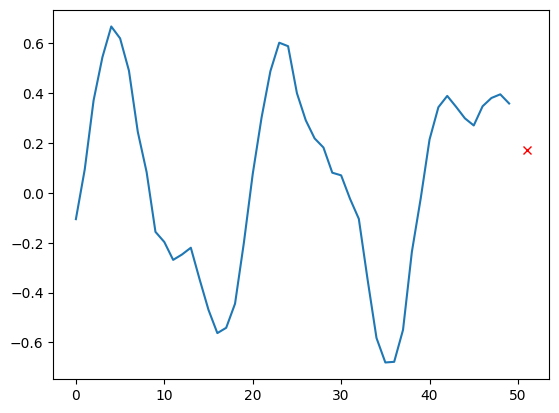

In [19]:
plt.figure()
plt.plot(X_train[0])
plt.plot(n_steps+1, y_train[0], 'rx')

### 1.4 Simple Linear model

In [20]:
# Model definition
model_linear = Sequential()
model_linear.add(Flatten(input_shape=(50,1)))
model_linear.add(Dense(1, activation = None))

In [21]:
# Model building

learning_rate = 0.001
optimizer = Adam(learning_rate)
model_linear.compile(loss='mean_squared_error', optimizer=optimizer, metrics=['mean_squared_error'])

In [22]:
model_linear.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51 (204.00 B)

 Trainable params: 51 (204.00 B)

 Non-trainable params: 0 (0.00 B)

In [23]:
# Model training

history_linear = model_linear.fit(X_train, y_train, epochs=no_training_epochs, validation_data=[X_valid, y_valid])

Epoch 1/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1231 - mean_squared_error: 0.1231 - val_loss: 0.0512 - val_mean_squared_error: 0.0512
Epoch 2/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0333 - mean_squared_error: 0.0333 - val_loss: 0.0218 - val_mean_squared_error: 0.0218
Epoch 3/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0169 - mean_squared_error: 0.0169 - val_loss: 0.0131 - val_mean_squared_error: 0.0131
Epoch 4/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0119 - mean_squared_error: 0.0119 - val_loss: 0.0105 - val_mean_squared_error: 0.0105
Epoch 5/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0100 - mean_squared_error: 0.0100 - val_loss: 0.0090 - val_mean_squared_error: 0.0090


In [24]:
def plot_function(history):
  plt.figure()

  plt.plot(history.history['loss'], label='loss')
  plt.plot(history.history['val_loss'], label='validation_loss')
  plt.legend()
  plt.grid()
  plt.xlim([0,no_training_epochs-1])
  plt.xlabel('epochs')

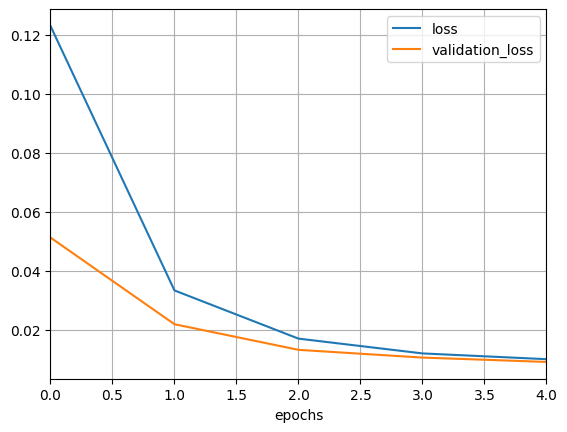

In [25]:
plot_function(history_linear)

In [26]:
score = model_linear.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print(f'Test MSE: ', score[1])

Test loss: 0.00872077140957117
Test MSE:  0.00872077140957117


### 1.5 Simple RNN Model

In [27]:
model_simple_rnn = Sequential()
model_simple_rnn.add(SimpleRNN(1, input_shape=[50, 1]))

In [28]:
learning_rate_simple_rnn = 0.001
optimizer_simple_rnn = Adam(learning_rate_simple_rnn)
model_simple_rnn.compile(loss='mean_squared_error', optimizer=optimizer_simple_rnn, metrics=['mean_squared_error'])

In [29]:
history_simple_rnn = model_simple_rnn.fit(X_train, y_train, epochs=no_training_epochs, validation_data=[X_valid, y_valid])

Epoch 1/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.2882 - mean_squared_error: 0.2882 - val_loss: 0.2668 - val_mean_squared_error: 0.2668
Epoch 2/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2458 - mean_squared_error: 0.2458 - val_loss: 0.2269 - val_mean_squared_error: 0.2269
Epoch 3/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2082 - mean_squared_error: 0.2082 - val_loss: 0.1915 - val_mean_squared_error: 0.1915
Epoch 4/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1764 - mean_squared_error: 0.1764 - val_loss: 0.1625 - val_mean_squared_error: 0.1625
Epoch 5/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1510 - mean_squared_error: 0.1510 - val_loss: 0.1399 - val_mean_squared_error: 0.1399


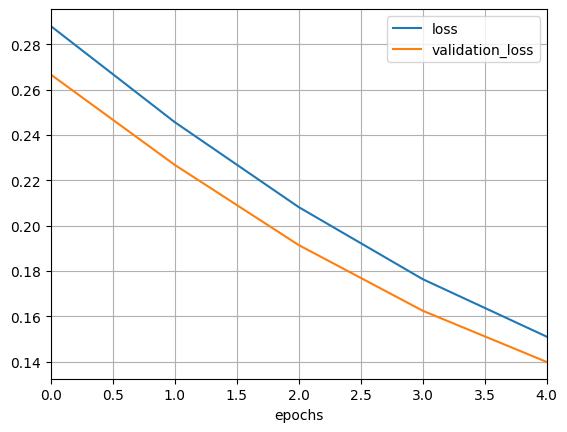

In [30]:
plot_function(history_simple_rnn)

### 1.5 Deep RNN Model

In [31]:
model_deep_rnn = Sequential()
model_deep_rnn.add(SimpleRNN(20, return_sequences = True, input_shape=[50, 1]))
model_deep_rnn.add(SimpleRNN(20, return_sequences = True))
model_deep_rnn.add(SimpleRNN(1, input_shape=[50, 1]))

In [32]:
learning_rate_deep_rnn = 0.001
optimizer_deep_rnn = Adam(learning_rate_deep_rnn)
model_deep_rnn.compile(loss='mean_squared_error', optimizer=optimizer_deep_rnn, metrics=['mean_squared_error'])

In [33]:
history_deep_rnn = model_deep_rnn.fit(X_train, y_train, epochs=no_training_epochs, validation_data=[X_valid, y_valid])

Epoch 1/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - loss: 0.0782 - mean_squared_error: 0.0782 - val_loss: 0.0095 - val_mean_squared_error: 0.0095
Epoch 2/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0062 - mean_squared_error: 0.0062 - val_loss: 0.0050 - val_mean_squared_error: 0.0050
Epoch 3/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0046 - mean_squared_error: 0.0046 - val_loss: 0.0043 - val_mean_squared_error: 0.0043
Epoch 4/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0040 - mean_squared_error: 0.0040 - val_loss: 0.0035 - val_mean_squared_error: 0.0035
Epoch 5/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0037 - mean_squared_error: 0.0037 - val_loss: 0.0032 - val_mean_squared_error: 0.0032


In [34]:
score = model_deep_rnn.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print(f'Test MSE: ', score[1])

Test loss: 0.003262012032791972
Test MSE:  0.003262012032791972


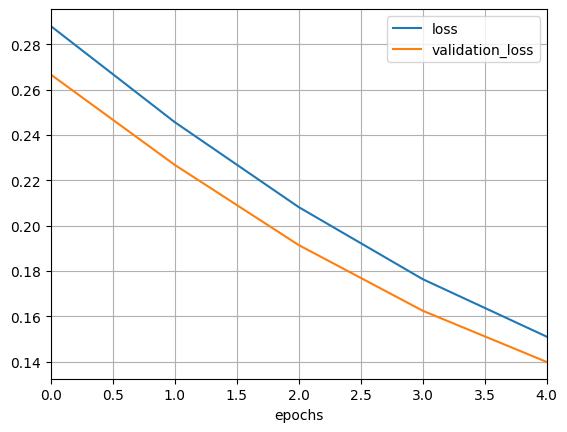

In [35]:
plot_function(history_simple_rnn)

## Exercise 2 - The movie review




Based on the written rewiev, classify if the movie if good or bad

### 2.0 - Import libraries

In [36]:
#from keras.preprocessing.text import Tokenizer
import keras
import numpy as np
from keras.models import Sequential
from keras.layers import LSTM, Dense, Embedding, SimpleRNN, GRU
from keras.preprocessing.sequence import pad_sequences
import matplotlib.pyplot as plt
from keras.optimizers import Adam

### 2.1 - Load dataset

In [37]:
(X_train, y_train), (X_test, y_test) = keras.datasets.imdb.load_data()

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


### 2.2 - Dataset examination

In [38]:
word_index = keras.datasets.imdb.get_word_index()
id_to_word = {id_ + 3:word for word, id_ in word_index.items()}
for id_, token in enumerate(("<pad>", "<sos>", "<unk>")):
  id_to_word[id_] = token

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [39]:
single_sequence = " ".join([id_to_word[id_] for id_ in X_train[0][:]])

In [40]:
single_sequence

"<sos> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert redford's is an amazing actor and now the same being director norman's father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for retail and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also congratulations to the two little boy's that played the part's of norman and paul they were just brilliant children are often left out of the praising list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and shou

In [41]:
max_length = 150  # Define the maximum length of a review
X_train = keras.preprocessing.sequence.pad_sequences(X_train, maxlen=max_length, padding='post', truncating='post', value=0)
X_test = keras.preprocessing.sequence.pad_sequences(X_test, maxlen=max_length, padding='post', truncating='post', value=0)

In [42]:
embed_size = 128
vocabulary_size = 1000

model = keras.models.Sequential([
    keras.layers.Embedding(vocabulary_size, embed_size,
                           input_shape=[None]),
    keras.layers.SimpleRNN(128, return_sequences=True),
    keras.layers.SimpleRNN(128),
    keras.layers.Dense(1, activation='sigmoid')
    ])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [43]:
optimizer = Adam(learning_rate = 0.001)

In [44]:
model.compile(loss="binary_crossentropy", optimizer=optimizer, metrics=["accuracy"])

In [45]:
history = model.fit(X_train, y_train, epochs=5, validation_split=0.2)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 27ms/step - accuracy: 0.4997 - loss: 0.7152 - val_accuracy: 0.5062 - val_loss: 0.6976
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 26ms/step - accuracy: 0.4945 - loss: 0.6963 - val_accuracy: 0.5062 - val_loss: 0.6955
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.4994 - loss: 0.6960 - val_accuracy: 0.4938 - val_loss: 0.6950
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.5005 - loss: 0.6957 - val_accuracy: 0.4938 - val_loss: 0.7028
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 25ms/step - accuracy: 0.4996 - loss: 0.6959 - val_accuracy: 0.5062 - val_loss: 0.6936


In [46]:
score = model.evaluate(X_test, y_test, verbose=0)
print('Test loss:', score[0])
print(f'Test accuracy: ', score[1]*100, "%")

Test loss: 0.6941896080970764
Test accuracy:  50.0 %


TASK: Modify structure, change the core of the network from RNN to LTSM and GRU. Compare the results

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 0.2633 - mean_squared_error: 0.2633 - val_loss: 0.2564 - val_mean_squared_error: 0.2564
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.2541 - mean_squared_error: 0.2541 - val_loss: 0.2513 - val_mean_squared_error: 0.2513
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 0.2531 - mean_squared_error: 0.2531 - val_loss: 0.2530 - val_mean_squared_error: 0.2530
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 0.2535 - mean_squared_error: 0.2535 - val_loss: 0.2506 - val_mean_squared_error: 0.2506
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 0.2529 - mean_squared_error: 0.2529 - val_loss: 0.2515 - val_mean_squared_error: 0.2515
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.2528 - mean_squared_error: 0.2528 - val_loss: 0.2510 - val_mean_squared_error: 0.2510
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 0.2527 - mean_squared_error: 0.2527 - val_los

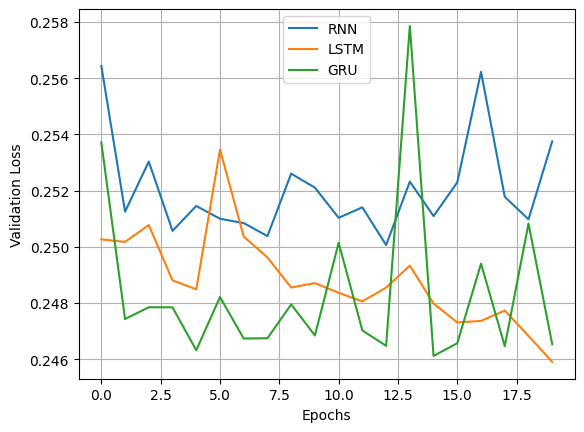

In [47]:

import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU
from tensorflow.keras.optimizers import Adam





# MODELO 1: RNN SIMPLE

model_rnn = Sequential()
model_rnn.add(SimpleRNN(32, input_shape=(50,1)))
model_rnn.add(Dense(1))

model_rnn.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mean_squared_error',
    metrics=['mean_squared_error']
)



# MODELO 2: LSTM

model_lstm = Sequential()
model_lstm.add(LSTM(32, input_shape=(50,1)))
model_lstm.add(Dense(1))

model_lstm.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mean_squared_error',
    metrics=['mean_squared_error']
)



# MODELO 3: GRU

model_gru = Sequential()
model_gru.add(GRU(32, input_shape=(50,1)))
model_gru.add(Dense(1))

model_gru.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mean_squared_error',
    metrics=['mean_squared_error']
)



epochs = 20

history_rnn = model_rnn.fit(
    X_train, y_train,
    epochs=epochs,
    validation_split=0.2,
    verbose=1
)

history_lstm = model_lstm.fit(
    X_train, y_train,
    epochs=epochs,
    validation_split=0.2,
    verbose=1
)

history_gru = model_gru.fit(
    X_train, y_train,
    epochs=epochs,
    validation_split=0.2,
    verbose=1
)



print("\nResultados finales (val_loss):")
print("RNN :", history_rnn.history['val_loss'][-1])
print("LSTM:", history_lstm.history['val_loss'][-1])
print("GRU :", history_gru.history['val_loss'][-1])



plt.figure()

plt.plot(history_rnn.history['val_loss'], label='RNN')
plt.plot(history_lstm.history['val_loss'], label='LSTM')
plt.plot(history_gru.history['val_loss'], label='GRU')

plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.legend()
plt.grid()

plt.show()